# Chapter 114 — Affine Transformations

> **Prerequisites:** ch109–113 (All Transforms)
>
> **Outcomes:** Define affine transformations as linear + translation; Express all 2D transforms in homogeneous coordinates; Understand the 6 degrees of freedom in 2D affine maps; Apply to image warping and coordinate changes


## The Affine Framework

An **affine transformation** is: x' = A·x + t
where A is a 2×2 matrix (linear part) and t is a translation vector.

Combined in homogeneous coordinates:
[x'; y'; 1] = [[A₁₁, A₁₂, tx], [A₂₁, A₂₂, ty], [0, 0, 1]] · [x; y; 1]

This 3×3 matrix encodes all 2D transformations:
- A = R(θ): rotation
- A = S(sx,sy): scaling
- A = F(θ): reflection
- t = (dx,dy): translation
- A = shear: A₁₂ or A₂₁ nonzero

**6 degrees of freedom:** 4 entries in A + 2 in t = 6 parameters.

**Affine maps preserve:**
- Straight lines → straight lines
- Parallel lines → parallel lines (ratio of lengths preserved along parallel lines)
- NOT necessarily: angles, distances, or shapes

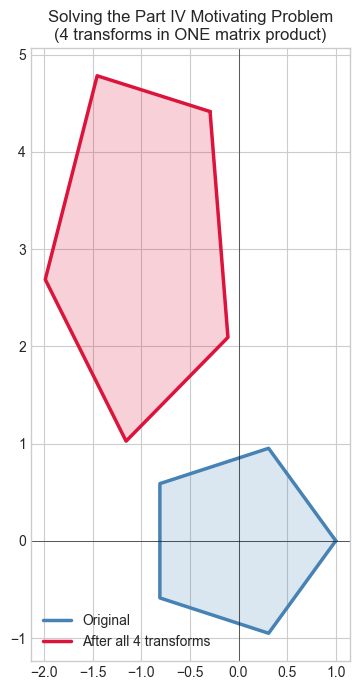

Composite matrix:
[[ 0.7071  0.7071 -1.    ]
 [ 1.4142 -1.4142  3.    ]
 [ 0.      0.      1.    ]]


In [2]:
# --- Affine transformation framework ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

class AffineTransform:
    """2D affine transformation using 3×3 homogeneous matrix."""
    
    def __init__(self, matrix=None):
        self.M = matrix if matrix is not None else np.eye(3)
    
    @classmethod
    def rotation(cls, theta):
        c,s = np.cos(theta),np.sin(theta)
        return cls(np.array([[c,-s,0],[s,c,0],[0,0,1]]))
    
    @classmethod
    def translation(cls, dx, dy):
        return cls(np.array([[1,0,dx],[0,1,dy],[0,0,1]],dtype=float))
    
    @classmethod
    def scale(cls, sx, sy):
        return cls(np.array([[sx,0,0],[0,sy,0],[0,0,1]],dtype=float))
    
    @classmethod
    def shear(cls, shx=0, shy=0):
        return cls(np.array([[1,shx,0],[shy,1,0],[0,0,1]],dtype=float))
    
    def __matmul__(self, other):
        """Compose: self THEN other."""
        return AffineTransform(other.M @ self.M)
    
    def apply(self, points):
        pts = np.asarray(points, dtype=float)
        h = np.hstack([pts, np.ones((len(pts),1))])
        out = (self.M @ h.T).T
        return out[:,:2]
    
    def inverse(self):
        return AffineTransform(np.linalg.inv(self.M))

# Apply to the motivating problem from Part IV intro
theta = np.linspace(0, 2*np.pi, 6)[:-1]
pentagon = np.column_stack([np.cos(theta), np.sin(theta)])

# Chain: rotate 45° → scale x by 2 → translate (3,-1) → reflect across y=x
T_chain = (AffineTransform.rotation(np.radians(45)) @
           AffineTransform.scale(2, 1) @
           AffineTransform.translation(3, -1) @
           AffineTransform(np.array([[0,1,0],[1,0,0],[0,0,1]])))  # reflect y=x

result = T_chain.apply(pentagon)

fig, ax = plt.subplots(figsize=(10, 7))
closed = lambda p: np.vstack([p,p[0]])
ax.fill(pentagon[:,0],pentagon[:,1],alpha=0.2,color='steelblue')
ax.plot(closed(pentagon)[:,0],closed(pentagon)[:,1],'steelblue',lw=2.5,label='Original')
ax.fill(result[:,0],result[:,1],alpha=0.2,color='crimson')
ax.plot(closed(result)[:,0],closed(result)[:,1],'crimson',lw=2.5,label='After all 4 transforms')
ax.set_aspect('equal'); ax.legend(fontsize=10)
ax.set_title('Solving the Part IV Motivating Problem\n(4 transforms in ONE matrix product)')
ax.axhline(0, color='k', linewidth=0.4); ax.axvline(0, color='k', linewidth=0.4)
plt.tight_layout(); plt.show()
print("Composite matrix:")
print(T_chain.M.round(4))

## Image Warping



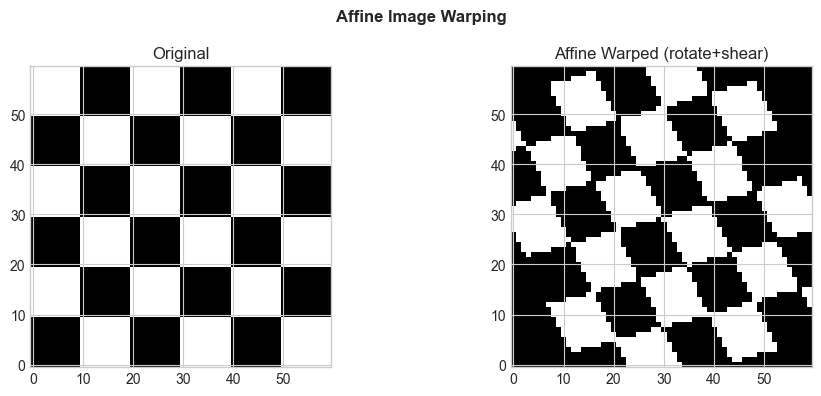

In [3]:
# --- Affine image warp demo ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

# Create synthetic 'image' (checkerboard)
N = 60
img = np.zeros((N, N))
for i in range(N):
    for j in range(N):
        img[i,j] = (i//10 + j//10) % 2

# Affine warp: rotation 15° + slight shear
theta = np.radians(15)
c, s = np.cos(theta), np.sin(theta)
# Map output pixel → input pixel (inverse warp)
A_inv = np.linalg.inv(np.array([[c,-s],[s,c]])) @ np.array([[1,0.2],[0,1]])

cx, cy = N/2, N/2
warped = np.zeros_like(img)
for oy in range(N):
    for ox in range(N):
        src = A_inv @ np.array([ox-cx, oy-cy]) + np.array([cx, cy])
        sx, sy = int(round(src[0])), int(round(src[1]))
        if 0 <= sx < N and 0 <= sy < N:
            warped[oy, ox] = img[sy, sx]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img, cmap='gray', origin='lower'); axes[0].set_title('Original')
axes[1].imshow(warped, cmap='gray', origin='lower'); axes[1].set_title('Affine Warped (rotate+shear)')
plt.suptitle('Affine Image Warping', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

## Summary

- Affine transform: x' = Ax + t — combines any linear map with translation
- 3×3 homogeneous matrix unifies all 2D transforms in one product
- 6 DOF: 4 matrix entries + 2 translation values
- Affine preserves lines and parallelism; projective transforms (beyond this book) add perspective

**This chapter resolves the Part IV motivating problem completely.**

**Forward:** ch164 (Linear Transformations) generalizes to N dimensions; ch175 (PCA) uses orthogonal transformations (rotations) to find principal axes.